In [1]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import json
import requests
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay, f1_score)
import optuna
from lightgbm import LGBMClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

### Exploración de los datos

In [2]:
#Se levanta el csv
df = pd.read_csv(r"\Users\MSI\OneDrive\Challenge Meli\user_logins.csv")
df.head()

,user_id,login_time,ip_address,device_type
0,user_56,2024-08-26 00:00:00,192.168.1.47,tablet
1,user_62,2024-08-26 00:00:00,192.168.1.27,mobile
2,user_68,2024-08-26 00:00:00,192.168.1.19,tablet
3,user_9,2024-08-26 00:03:00,192.168.1.44,desktop
4,user_92,2024-08-26 00:13:00,192.168.1.18,tablet


In [3]:
#Se muestra la información del df, el tipo de dato y si hay nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18941 entries, 0 to 18940
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      18941 non-null  str  
 1   login_time   18941 non-null  str  
 2   ip_address   18941 non-null  str  
 3   device_type  18941 non-null  str  
dtypes: str(4)
memory usage: 592.0 KB


Hay que modificar el tipo de dato de login_time porque aparece como tipo texto. Hay que pasarlo a datetime para luego poder analizar por un lado la fecha y por otro la hora

In [4]:
#Se convierte la columna login_time a formato datetime
df['login_time'] = pd.to_datetime(df['login_time'])

#Se muestran estadísticas generales del df
print(f'Registros totales: {len(df):,}')
print(f'Usuarios únicos:   {df["user_id"].nunique()}')
print(f'IPs únicas:        {df["ip_address"].nunique():,}')
print(f'Tipos de device:   {df["device_type"].unique().tolist()}')
print(f'Rango temporal:    {df["login_time"].min()} → {df["login_time"].max()}')
print(f'Cantidad de días:  {(df["login_time"].max() - df["login_time"].min()).days}')

Registros totales: 18,941
Usuarios únicos:   100
IPs únicas:        1,655
Tipos de device:   ['tablet', 'mobile', 'desktop']
Rango temporal:    2024-08-26 00:00:00 → 2024-12-31 23:16:00
Cantidad de días:  127


In [5]:
#Reviso la info nuevamente para verificar el tipo de dato de login_time
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18941 entries, 0 to 18940
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      18941 non-null  str           
 1   login_time   18941 non-null  datetime64[us]
 2   ip_address   18941 non-null  str           
 3   device_type  18941 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 592.0 KB


In [6]:
#Se crean features temporales a partir de login_time, como hora, día de la semana, si es fin de semana o no, y si es horario nocturno o no.
df['hour']       = df['login_time'].dt.hour
df['day_of_week']= df['login_time'].dt.dayofweek   # 0=Lunes, 6=Domingo
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_night']   = df['hour'].between(0, 5).astype(int)  # 00:00 - 05:59
df['date']       = df['login_time'].dt.date

In [7]:
df.head()

,user_id,login_time,ip_address,device_type,hour,day_of_week,is_weekend,is_night,date
0,user_56,2024-08-26 00:00:00,192.168.1.47,tablet,0,0,0,1,2024-08-26
1,user_62,2024-08-26 00:00:00,192.168.1.27,mobile,0,0,0,1,2024-08-26
2,user_68,2024-08-26 00:00:00,192.168.1.19,tablet,0,0,0,1,2024-08-26
3,user_9,2024-08-26 00:03:00,192.168.1.44,desktop,0,0,0,1,2024-08-26
4,user_92,2024-08-26 00:13:00,192.168.1.18,tablet,0,0,0,1,2024-08-26


### Visualizaciones

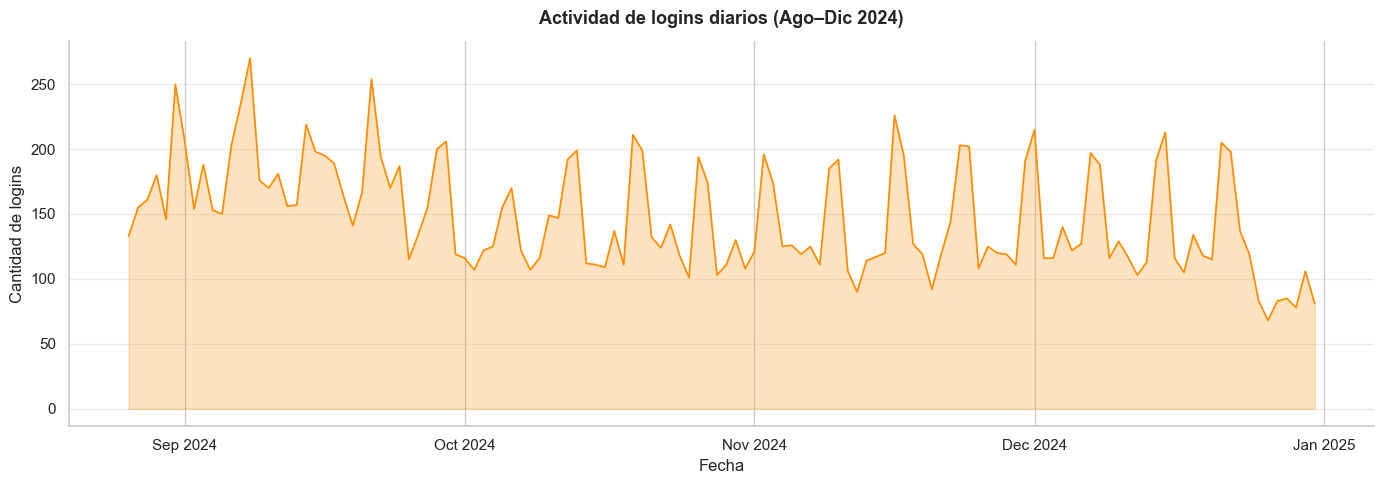

In [9]:
daily = df.groupby('date').size()

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(daily.index, daily.values, alpha=0.25, color='darkorange')
ax.plot(daily.index, daily.values, color='darkorange', linewidth=1.2)

ax.set_title('Actividad de logins diarios (Ago–Dic 2024)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de logins')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=0)

ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()


En el grafico se evidencian picos y caidas constantes, que pueden ser por el ciclo semana/fin de semana. Esto dificulta el analisis para ver si los logueos estan efectivamente subiendo, bajando o si se mantienen estables en el tiempo. Por esta razon se agregara una linea de media movil de 7 dias, asi se podra visualizar de manera mas nitida la verdadera tendencia.

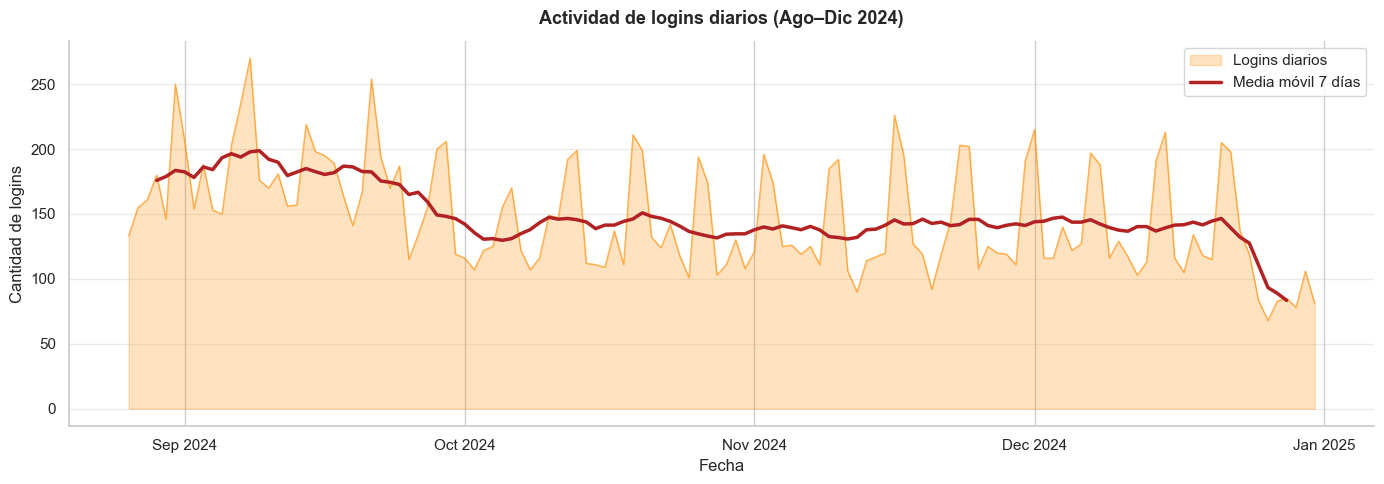

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

# Línea suavizada (media móvil 7 días) para ver tendencia
daily_smooth = daily.rolling(7, center=True).mean()

ax.fill_between(daily.index, daily.values, alpha=0.25, color='darkorange', label='Logins diarios')
ax.plot(daily.index, daily.values, color='darkorange', linewidth=1, alpha=0.6)
ax.plot(daily.index, daily_smooth.values, color='firebrick', linewidth=2.5, 
        label='Media móvil 7 días')

ax.set_title('Actividad de logins diarios (Ago–Dic 2024)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de logins')

# Fechas legibles
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))
ax.tick_params(axis='x', rotation=0)

ax.legend()
ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

Con la linea de media movil, se ve que el numero de logueos fue bajando entre fines de agosto hacia fines de diciembre, pasando de unos 200 logueos aproximadamente a 100.

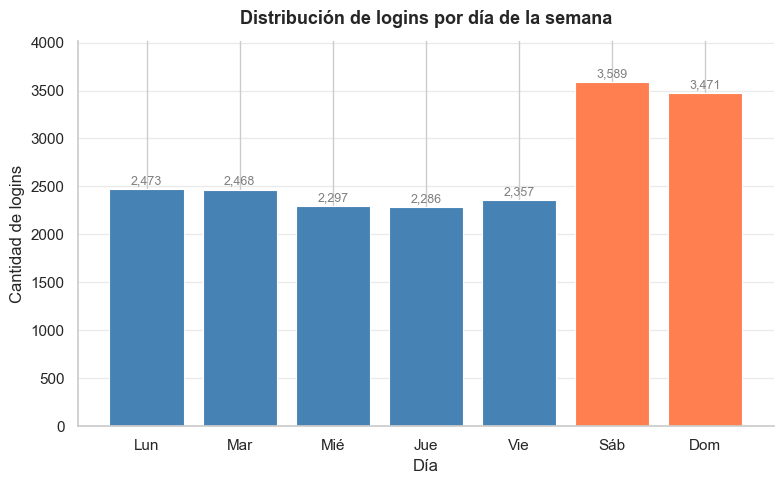

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
valores = df['day_of_week'].value_counts().sort_index()

# Colorear diferente los fines de semana para destacarlos
colores = ['steelblue' if i < 5 else 'coral' for i in range(7)]

bars = ax.bar(dias, valores, color=colores, edgecolor='white', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, color='gray')

ax.set_title('Distribución de logins por día de la semana', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Día')
ax.set_ylabel('Cantidad de logins')
ax.set_ylim(0, valores.max() * 1.12) 
ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

En el grafico se evidencia que durante los dias de semana la cantidad de logueos es estable, se destaca un aumento durante el fin de semana. Esto terminaria de corroborar que los picos que se veian en la visualización anterior correspondian al fin de semana y las caidas a los dias de semana.

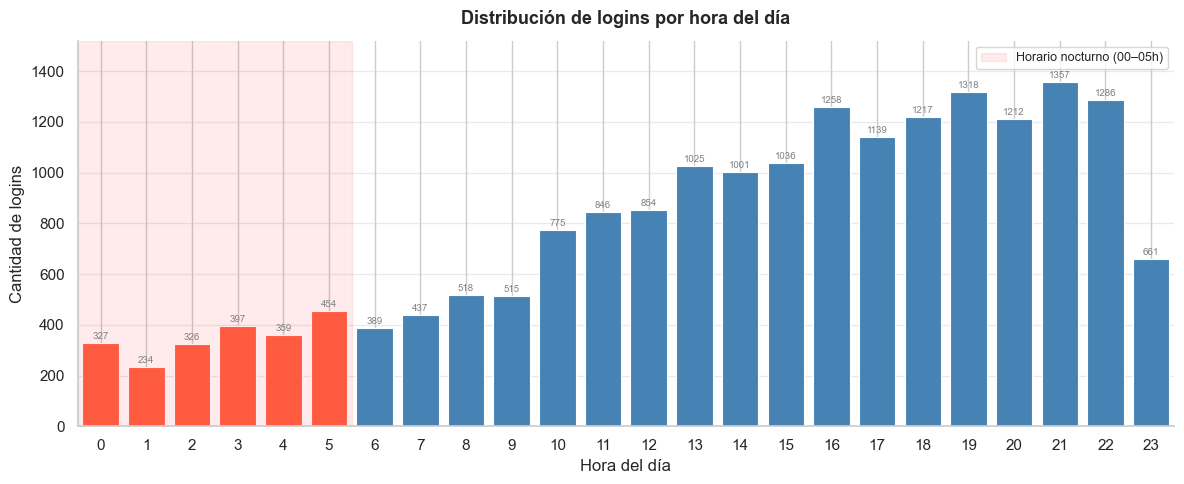

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

horas = df['hour'].value_counts().sort_index()

# Colorear horas nocturnas (00-05) en rojo
colores = ['tomato' if h < 6 else 'steelblue' for h in horas.index]

bars = ax.bar(horas.index, horas.values, color=colores, edgecolor='white', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=7, color='gray')

# Sombreado zona nocturna
ax.axvspan(-0.5, 5.5, alpha=0.08, color='red', label='Horario nocturno (00–05h)')

ax.set_title('Distribución de logins por hora del día', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Cantidad de logins')
ax.set_xticks(range(24))
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, horas.max() * 1.12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

Para esta visualización se considero pertinente resaltar aquellas horas donde es mas inusual que un usuario se este logueando, definiendo ese rango horario entre las 24:00 am y las 5:00 am. En primera instancia se ve que la cantidad de logueos en esa franja horaria es bastante estable, teniendo un pico a las 5:00 am. En la primera mañana el numero de logueos es muy similar a ese pico a las 5:00 am. Durante la tarde y la noche es donde se registran la mayor cantidad de logueos, cayendo considerablemente entre las 22:00 pm y 23:00 pm.

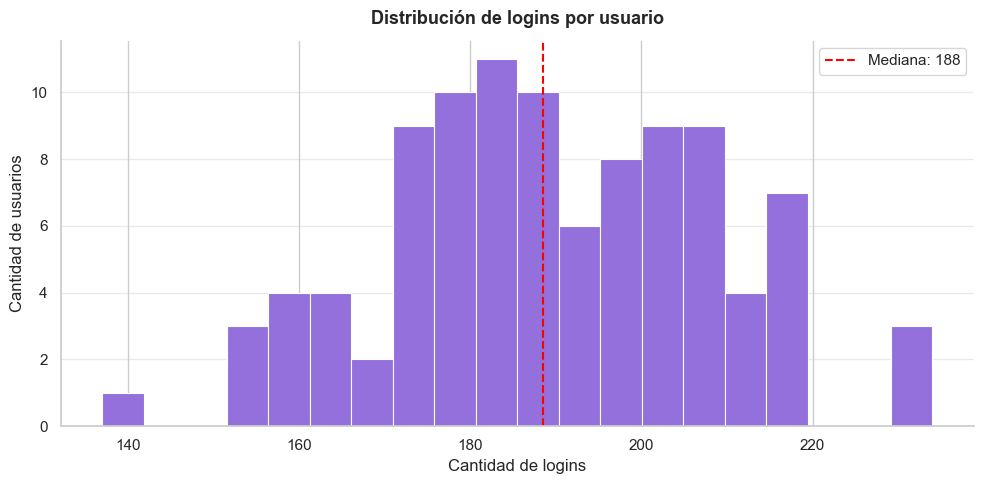

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

logins_per_user = df.groupby('user_id').size()
mediana = logins_per_user.median()

ax.hist(logins_per_user.values, bins=20, color='mediumpurple', edgecolor='white', linewidth=0.8)
ax.axvline(mediana, color='red', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:.0f}')

ax.set_title('Distribución de logins por usuario', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cantidad de logins')
ax.set_ylabel('Cantidad de usuarios')
ax.legend()
ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

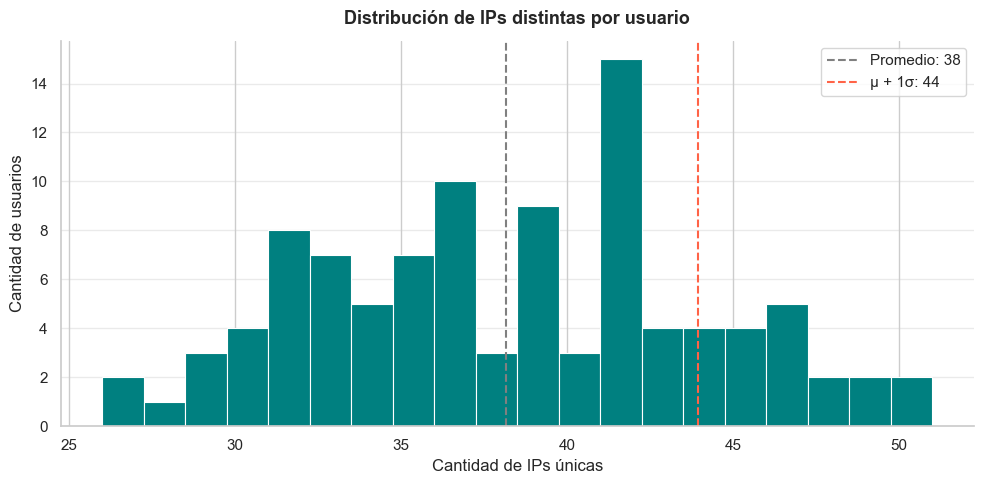

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ips_per_user = df.groupby('user_id')['ip_address'].nunique()
media = ips_per_user.mean()
umbral = media + ips_per_user.std()

ax.hist(ips_per_user.values, bins=20, color='teal', edgecolor='white', linewidth=0.8)
ax.axvline(media, color='gray', linestyle='--', linewidth=1.5, label=f'Promedio: {media:.0f}')
ax.axvline(umbral, color='tomato', linestyle='--', linewidth=1.5, label=f'μ + 1σ: {umbral:.0f}')

ax.set_title('Distribución de IPs distintas por usuario', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cantidad de IPs únicas')
ax.set_ylabel('Cantidad de usuarios')
ax.legend()
ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

El grafico muestra que la cantidad de promedio de IPs por usuario es de 38, para tratar de identificar cual seria una cantidad "inusual" se le agrega una desviación estándar. En conclusión, en base a la estadistica, aquellos usuarios que tengan mas de 44 IPs deberian ser revisados.

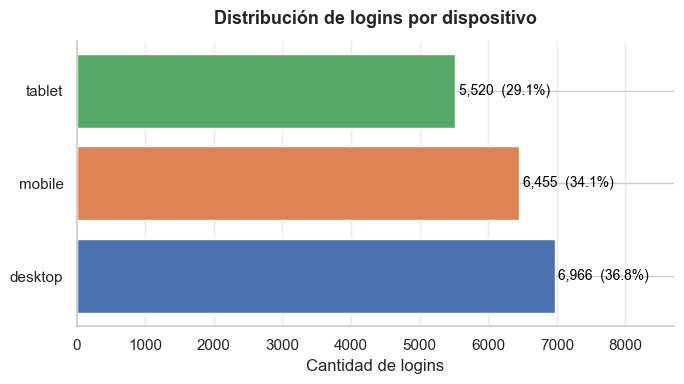

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

device_counts = df['device_type'].value_counts()
colores = ['#4C72B0', '#DD8452', '#55A868']

bars = ax.barh(device_counts.index, device_counts.values, color=colores, edgecolor='white')

# Etiquetas con valor y porcentaje
total = device_counts.sum()
for bar, val in zip(bars, device_counts.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/total*100:.1f}%)',
            va='center', fontsize=10, color='black')

ax.set_title('Distribución de logins por dispositivo', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cantidad de logins')
ax.set_xlim(0, device_counts.max() * 1.25)  
ax.grid(axis='x', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

La visualización evidencia que practicamente no hay una diferencia significativa entre los dispositivos mediantes los cuales los usuarios se loguean. El mas usado es por computadora y el menos la tablet.

## Reglas de normalidad

#### En base a las visualizaciones y los datos estadisticos se implementaran las siguientes reglas para poder identificar aquellos logueos inusuales o sospechosos:

R1 **Hora inusual** : Login fuera del rango horario habitual del usuario (media ± 2σ o fuera del percentil 5-95) <br>
R2 **IP nueva** : IP no vista en los primeros 80% del historial del usuario <br>
R3 **Device inusual** : Dispositivo no habitual para ese usuario <br>
R4 **Horario nocturno** : Login entre 00:00 y 05:59 <br>
R5 **Alta frecuencia** : Cantidad de logins alta en una ventana de 1 hora <br>
R6 **Fin de semana** : Login en fin de semana, si el usuario nunca lo hace <br>

In [16]:
def build_user_baselines(df: pd.DataFrame) -> dict:
    """
    Construye el perfil de comportamiento normal para cada usuario
    usando el 80% más antiguo de su historial como período de entrenamiento.
    """
    baselines = {}
    
    for user, group in df.groupby('user_id'):
        group_sorted = group.sort_values('login_time')
        cutoff_idx   = int(len(group_sorted) * 0.8)
        train        = group_sorted.iloc[:cutoff_idx]
        #Para cada usuario, agarra todos sus logins y los ordena por fecha. Después calcula el índice del 80% 
        #Si el usuario tiene 100 logins, cutoff_idx es 80. 
        #train son los primeros 80 logins, el período de entrenamiento.
        
        hours = train['hour']
        baselines[user] = {
            # Rango horario normal: percentil 5 a 95
            'hour_p5':           hours.quantile(0.05),
            'hour_p95':          hours.quantile(0.95),
            'hour_mean':         hours.mean(),
            'hour_std':          hours.std() if hours.std() > 0 else 1,
            # IPs conocidas
            'known_ips':         set(train['ip_address']),  #Se usa set para armar una lista sin duplicados de las IPs usadas por el usuario en el período de entrenamiento
            # Devices habituales
            'known_devices':     set(train['device_type']),
            # Para identificar si se loguea los fines de semana
            'uses_weekend':      (train['is_weekend'] == 1).any(),
            # Total de logins en período de entrenamiento (para normalizar freq)
            'train_days':        max((train['login_time'].max() - train['login_time'].min()).days, 1),
            'avg_daily_logins':  len(train) / max((train['login_time'].max() - train['login_time'].min()).days, 1),
        }
    
    return baselines

baselines = build_user_baselines(df)
print(f'✅ Baselines construidos para {len(baselines)} usuarios')
print()
print('Ejemplo — user_1:')
b = baselines.get('user_1', {})
for k, v in b.items():
    if k not in ('known_ips',):
        print(f'  {k}: {v}')
print(f'  known_ips: {len(b["known_ips"])} IPs')

✅ Baselines construidos para 100 usuarios

Ejemplo — user_1:
  hour_p5: 2.1000000000000005
  hour_p95: 20.900000000000006
  hour_mean: 12.965034965034965
  hour_std: 5.963991228364464
  known_devices: {'desktop', 'mobile', 'tablet'}
  uses_weekend: True
  train_days: 90
  avg_daily_logins: 1.5888888888888888
  known_ips: 38 IPs


In [17]:
# Calcular logins por usuario por hora para la regla de frecuencia
df_sorted = df.sort_values(['user_id', 'login_time']).copy()
df_sorted['login_hour_bucket'] = df_sorted['login_time'].dt.floor('h')
logins_per_hour = df_sorted.groupby(['user_id', 'login_hour_bucket']).size().reset_index(name='logins_in_hour')
df_sorted = df_sorted.merge(logins_per_hour, on=['user_id', 'login_hour_bucket'], how='left')

frecuencia_alta = 5  # más de 5 logins en 1 hora = sospechoso

def apply_anomaly_rules(row, baselines: dict) -> tuple:
    """
    Aplica las 6 reglas y retorna (is_anomaly, flags, score)
    - is_anomaly: 1 si se dispara al menos 1 regla, 0 si es normal
    - flags: lista de reglas disparadas
    - score: cantidad de reglas disparadas (severidad)
    """
    user = row['user_id']
    b = baselines.get(user)
    if b is None:
        return 0, [], 0
    
    flags = []
    
    # R1: Hora inusual (fuera de percentil 5-95)
    if not (b['hour_p5'] <= row['hour'] <= b['hour_p95']):
        flags.append('R1_hora_inusual')
    
    # R2: IP nueva (no vista en entrenamiento)
    if row['ip_address'] not in b['known_ips']:
        flags.append('R2_ip_nueva')
    
    # R3: Device inusual
    if row['device_type'] not in b['known_devices']:
        flags.append('R3_device_inusual')
    
    # R4: Horario nocturno
    if row['is_night'] == 1:
        flags.append('R4_horario_nocturno')
    
    # R5: Alta frecuencia (>5 logins en 1 hora)
    if row.get('logins_in_hour', 1) > frecuencia_alta:
        flags.append('R5_alta_frecuencia')
    
    # R6: Fin de semana si el usuario nunca lo hace
    if row['is_weekend'] == 1 and not b['uses_weekend']:
        flags.append('R6_weekend_inusual')
    
    score = len(flags)
    is_anomaly = 1 if score >= 1 else 0  # umbral: al menos 1 regla
    return is_anomaly, flags, score

results = df_sorted.apply(lambda row: apply_anomaly_rules(row, baselines), axis=1)
df_sorted['is_anomaly'] = results.apply(lambda x: x[0])
df_sorted['anomaly_flags'] = results.apply(lambda x: x[1])
df_sorted['anomaly_score'] = results.apply(lambda x: x[2])

In [18]:
#Con las reglas aplicadas, el 26% de los logins fueron etiquetados como anomalías.
df_sorted['is_anomaly'].value_counts(normalize=True).round(2)*100

is_anomaly
0    74.0
1    26.0
Name: proportion, dtype: float64

In [19]:
#El 22% de los logins tuvo una alerta (1 regla identificada) y un 4% tuvo 2 alertas.
df_sorted['anomaly_score'].value_counts(normalize=True).round(2)*100

anomaly_score
0    74.0
1    22.0
2     4.0
Name: proportion, dtype: float64

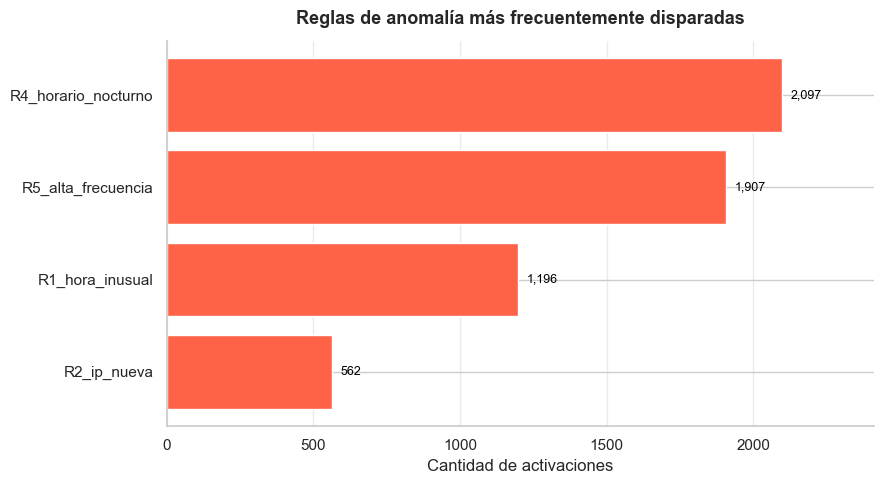

In [ ]:
#Reglas con mas frecuencias
all_flags = [f for flags in df_sorted['anomaly_flags'] for f in flags]
flag_counts = pd.Series(all_flags).value_counts()

fig, ax = plt.subplots(figsize=(9, 5))

flag_counts_sorted = flag_counts.sort_values()
colores = ['tomato'] * len(flag_counts_sorted)

bars = ax.barh(flag_counts_sorted.index, flag_counts_sorted.values, 
               color=colores, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9, color='black')

ax.set_title('Reglas de anomalía más frecuentemente disparadas', 
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cantidad de activaciones')
ax.set_xlim(0, flag_counts.max() * 1.15)
ax.grid(axis='x', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

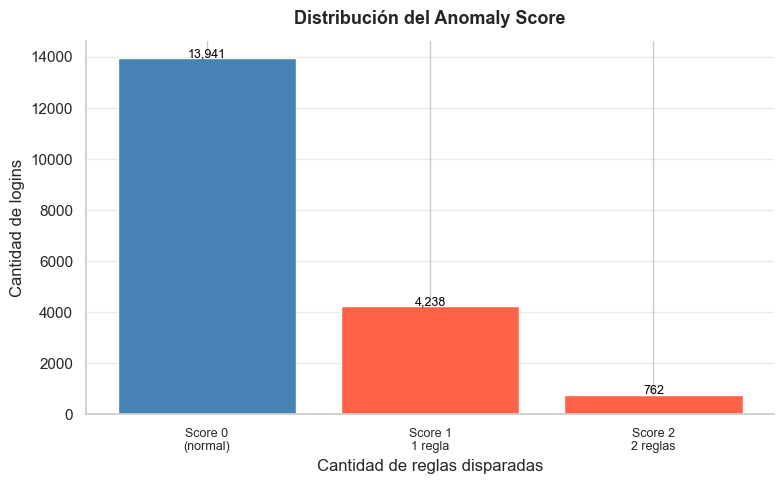

In [22]:
#Distribución de score
fig, ax = plt.subplots(figsize=(8, 5))

score_counts = df_sorted['anomaly_score'].value_counts().sort_index()
colores = ['steelblue' if i == 0 else 'tomato' for i in score_counts.index]

bars = ax.bar(score_counts.index, score_counts.values, 
              color=colores, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9, color='black')

ax.set_title('Distribución del Anomaly Score', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cantidad de reglas disparadas')
ax.set_ylabel('Cantidad de logins')
ax.set_xticks(score_counts.index)
ax.set_xticklabels([f'Score {i}\n{"(normal)" if i==0 else f"{i} regla{'s' if i>1 else ''}"}' 
                    for i in score_counts.index], fontsize=9)
ax.grid(axis='y', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

In [23]:
# Usuarios más sospechosos (mayor tasa de anomalías y mayor score promedio)
user_stats = df_sorted.groupby('user_id').agg(
    total_logins=('is_anomaly', 'count'),
    anomalias=('is_anomaly', 'sum'),
    avg_score=('anomaly_score', 'mean'),
    max_score=('anomaly_score', 'max'),
    ips_distintas=('ip_address', 'nunique'),
    devices_distintos=('device_type', 'nunique'),
    logins_nocturnos=('is_night', 'sum'),
    logins_weekend=('is_weekend', 'sum'),
).reset_index()

user_stats['pct_anomalia'] = user_stats['anomalias'] / user_stats['total_logins'] * 100
user_stats['risk_score'] = (
    user_stats['pct_anomalia'] * 0.4 +
    user_stats['avg_score'] * 20 +
    user_stats['ips_distintas'].rank(pct=True) * 20 +
    user_stats['logins_nocturnos'].rank(pct=True) * 20
).round(2)

top_risky = user_stats.nlargest(10, 'risk_score')
print('Top 10 usuarios más sospechosos:')
print(top_risky[['user_id','total_logins','anomalias','pct_anomalia',
                  'avg_score','ips_distintas','logins_nocturnos','risk_score']].to_string(index=False))

Top 10 usuarios más sospechosos:
user_id  total_logins  anomalias  pct_anomalia  avg_score  ips_distintas  logins_nocturnos  risk_score
user_64           205         91     44.390244   0.595122             45                59       66.46
 user_3           183         78     42.622951   0.459016             44                58       61.93
user_51           193         71     36.787565   0.450777             43                59       58.93
user_55           191         73     38.219895   0.460733             44                44       57.70
user_68           156         59     37.820513   0.474359             42                45       56.42
user_15           234         78     33.333333   0.371795             49                37       55.27
user_24           204         77     37.745098   0.431373             41                49       55.03
user_40           219         95     43.378995   0.461187             38                47       53.78
user_38           216         95     43.

### Reporte con la IA Generativa de GEMINI

In [ ]:
GEMINI_KEY = gemini_key
def generate_user_report(user_id, user_stats_row, sample_anomalies):
    anomaly_sample = sample_anomalies[['login_time','ip_address','device_type',
                                       'hour','anomaly_flags','anomaly_score']].head(5).to_string(index=False)
    
    prompt = f"""Eres un analista experto en ciberseguridad.

=== USUARIO: {user_id} ===
Total de logins: {user_stats_row['total_logins']}
Logins anómalos: {user_stats_row['anomalias']} ({user_stats_row['pct_anomalia']:.1f}%)
Score de anomalía promedio: {user_stats_row['avg_score']:.2f}
Score máximo: {user_stats_row['max_score']}
IPs distintas usadas: {user_stats_row['ips_distintas']}
Logins nocturnos (00:00-05:59): {user_stats_row['logins_nocturnos']}
Logins en fin de semana: {user_stats_row['logins_weekend']}
Risk score calculado: {user_stats_row['risk_score']:.1f}

Muestra de eventos sospechosos:
{anomaly_sample}

Generá un reporte con:
1. **Resumen ejecutivo** (2-3 oraciones)
2. **Patrones sospechosos detectados**
3. **Nivel de riesgo** (Bajo/Medio/Alto/Crítico) con justificación
4. **Recomendaciones** (2-3 acciones concretas)

No agregues introducción, título del reporte, fecha, firma ni despedida. Empezá directamente con el punto 1.
Sé específico y mantené un tono profesional."""

    try:
        response = requests.post(
            f'https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?key={GEMINI_KEY}',
            headers={'Content-Type': 'application/json'},
            json={'contents': [{'parts': [{'text': prompt}]}]},
            timeout=30
        )
        data = response.json()
        return data['candidates'][0]['content']['parts'][0]['text']
    except Exception as e:
        return f'[Error: {str(e)}]'

print('✅ Función definida con Gemini 2.5 Flash')

✅ Función definida con Gemini 2.5 Flash


In [40]:
top3_users = top_risky.head(3)['user_id'].tolist()
print(f'Usuarios seleccionados: {top3_users}')

reports = {}

for user_id in top3_users:
    print(f'\n📝 Generando reporte para {user_id}...')
    
    user_row = user_stats[user_stats['user_id'] == user_id].iloc[0]
    user_anomalies = df_sorted[
        (df_sorted['user_id'] == user_id) & 
        (df_sorted['is_anomaly'] == 1)
    ].sort_values('anomaly_score', ascending=False)
    
    report = generate_user_report(user_id, user_row, user_anomalies)
    reports[user_id] = report
    
    print('='*60)
    print(f'REPORTE DE SEGURIDAD — {user_id}')
    print('='*60)
    print(report)


Usuarios seleccionados: ['user_64', 'user_3', 'user_51']

📝 Generando reporte para user_64...
REPORTE DE SEGURIDAD — user_64
1.  **Resumen ejecutivo**
    El usuario user_64 presenta un patrón de actividad altamente anómalo, con un 44.4% de sus logins marcados como sospechosos y un elevado riesgo calculado de 66.5. Se observan múltiples accesos desde una gran cantidad de IPs distintas, actividad significativa durante horarios nocturnos y fines de semana, y picos de logins de alta frecuencia.

2.  **Patrones sospechosos detectados**
    *   **Alta proporción de anomalías**: Casi la mitad (44.4%) de los 205 logins registrados para user_64 fueron clasificados como anómalos.
    *   **Diversidad de IPs**: El uso de 45 IPs distintas es inusualmente alto para un único usuario, lo que podría indicar uso compartido de credenciales, compromiso o actividad a través de múltiples ubicaciones/VPNs.
    *   **Actividad fuera de horario**: 59 logins ocurrieron durante el horario nocturno (00:00-05:59

### Modelos de ML

In [24]:
# Copio el df para no pisar el original con las nuevas features para ML
df_ml = df_sorted.copy()

# La variable de tipo de dispositivo es categórica, la encodeamos con LabelEncoder para usarla en el modelo
le_device = LabelEncoder()
df_ml['device_enc'] = le_device.fit_transform(df_ml['device_type'])

# Agregar features de usuario (estadísticas históricas)
user_features = df_ml.groupby('user_id').agg(
    user_avg_hour=('hour', 'mean'),
    user_std_hour=('hour', 'std'),
    user_total_ips=('ip_address', 'nunique'),
    user_total_devices=('device_type', 'nunique'),
    user_night_rate=('is_night', 'mean'),
    user_weekend_rate=('is_weekend', 'mean'),
).reset_index()
user_features['user_std_hour'] = user_features['user_std_hour'].fillna(0)

df_ml = df_ml.merge(user_features, on='user_id', how='left')


# Features finales para el modelo
FEATURE_COLS = [
    'hour', 'day_of_week', 'is_weekend', 'is_night',
    'device_enc', 'logins_in_hour',
    'user_avg_hour', 'user_std_hour', 'user_total_ips',
    'user_total_devices', 'user_night_rate', 'user_weekend_rate'
]

TARGET_COL = 'is_anomaly'

X = df_ml[FEATURE_COLS].fillna(0)
y = df_ml[TARGET_COL]

print(f'Features: {FEATURE_COLS}')
print(f'Shape X: {X.shape}')
print(f'Distribución target:')
print(y.value_counts())
print(f'Ratio desbalance: {(y==0).sum()/(y==1).sum():.1f}:1')

Features: ['hour', 'day_of_week', 'is_weekend', 'is_night', 'device_enc', 'logins_in_hour', 'user_avg_hour', 'user_std_hour', 'user_total_ips', 'user_total_devices', 'user_night_rate', 'user_weekend_rate']
Shape X: (18941, 12)
Distribución target:
is_anomaly
0    13941
1     5000
Name: count, dtype: int64
Ratio desbalance: 2.8:1


El ratio de desbalance es de 2.8 logins normales por cada login anómalo. 
Se trata de un desbalance moderado. Como estrategia inicial se entrenará el 
modelo con class_weight='balanced', que penaliza más los errores en la clase 
minoritaria sin modificar los datos. Para comparar el rendimiento, se entrenará 
también el modelo con mejor rendimiento incorporando SMOTE, técnica que genera muestras 
sintéticas de la clase minoritaria para balancear el dataset.

In [25]:
# Train/test split estratificado (mantiene proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} muestras')
print(f'Test:  {len(X_test):,} muestras')
print(f'Train anomalías: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'Test  anomalías: {y_test.sum():,} ({y_test.mean()*100:.1f}%)')

Train: 15,152 muestras
Test:  3,789 muestras
Train anomalías: 4,000 (26.4%)
Test  anomalías: 1,000 (26.4%)


Se utilizarán dos algoritmos de ensamble para comparar el rendimiento:
Random Forest y LightGBM. Para la búsqueda de los mejores hiperparámetros se 
utilizará la librería Optuna, que optimiza automáticamente mediante búsqueda 
bayesiana en lugar de explorar el espacio de forma exhaustiva como Grid Search.

In [26]:
#Randrom Forest
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':      'balanced',
        'random_state':      42,
        'n_jobs':            -1
    }
    model = RandomForestClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()
    return score


rf_param = optuna.create_study(direction='maximize')
rf_param.optimize(objective_rf, n_trials=30, show_progress_bar=True)

print(f'Mejores params: {rf_param.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

Mejores params: {'n_estimators': 315, 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 6, 'max_features': 'sqrt'}


In [27]:
rf = RandomForestClassifier(**rf_param.best_params, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest — Reporte de clasificación:')  
print(classification_report(y_test, y_pred_rf))

Random Forest — Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2789
           1       0.99      0.86      0.92      1000

    accuracy                           0.96      3789
   macro avg       0.97      0.93      0.95      3789
weighted avg       0.96      0.96      0.96      3789



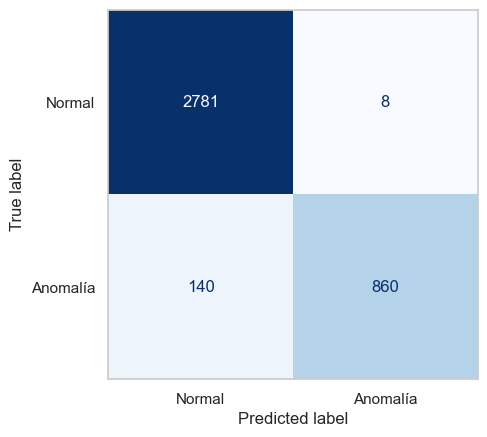

In [28]:
#Matriz de confusión para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=['Normal', 'Anomalía'])
disp.plot(cmap='Blues', colorbar=False)
disp.ax_.grid(False)
plt.show()

El modelo detecta correctamente el 86% de las anomalías (860/1000) y prácticamente no genera falsas alarmas, solo 8 logins normales fueron marcados como sospechosos. El principal margen de mejora está en los 140 falsos negativos, que representan el 14% de logins anómalos que pasaron desapercibidos. En un contexto de seguridad real estos serían los casos más costosos ya que implican ataques no detectados.

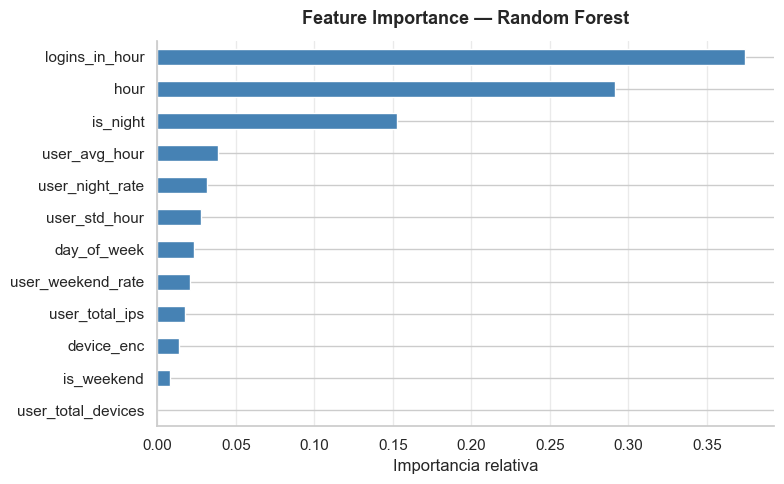

In [29]:
# Random Forest
feat_imp_rf = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp_rf.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importancia relativa')
ax.grid(axis='x', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

In [30]:
 #LightGBM 
def objective_lgbm(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 12),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':      trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'class_weight':    'balanced',
        'random_state':    42,
        'n_jobs':          -1,
        'verbose':         -1
    }
    model = LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()
    return score


lgbm_param = optuna.create_study(direction='maximize')
lgbm_param.optimize(objective_lgbm, n_trials=30, show_progress_bar=True)

print(f'Mejores params: {lgbm_param.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

Mejores params: {'n_estimators': 143, 'max_depth': 10, 'learning_rate': 0.10785477473835985, 'num_leaves': 20, 'min_child_samples': 25, 'subsample': 0.7148633048582047, 'colsample_bytree': 0.7196038854906297}


In [31]:
#Reporte de clasificación para LightGBM
lgbm = LGBMClassifier(**lgbm_param.best_params, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)  
y_pred_lgbm = lgbm.predict(X_test)
print('LightGBM — Reporte de clasificación:')
print(classification_report(y_test, y_pred_lgbm))

LightGBM — Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2789
           1       0.98      0.88      0.93      1000

    accuracy                           0.96      3789
   macro avg       0.97      0.93      0.95      3789
weighted avg       0.96      0.96      0.96      3789



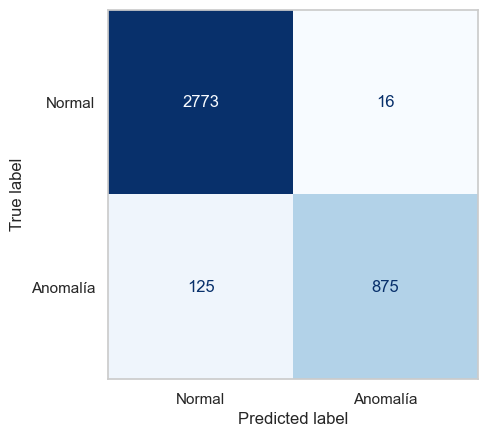

In [32]:
#Matriz de confusión para LightGBM
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
disp = ConfusionMatrixDisplay(cm_lgbm, display_labels=['Normal', 'Anomalía'])
disp.plot(cmap='Blues', colorbar=False)
disp.ax_.grid(False)
plt.show()

El modelo detecta correctamente el 87% de las anomalías (875/1000) y prácticamente no genera falsas alarmas, solo 16 logins normales fueron marcados como sospechosos. En comparación con el modelo de Random Forest, el de LightGBM tuvo un mejor rendimiento al identificar los logueos anomalos, pasando por alto 125 casos contra los 140 del modelo anterior. Aun hay margen de mejora para poder bajar lo mas que se pueda esos casos.

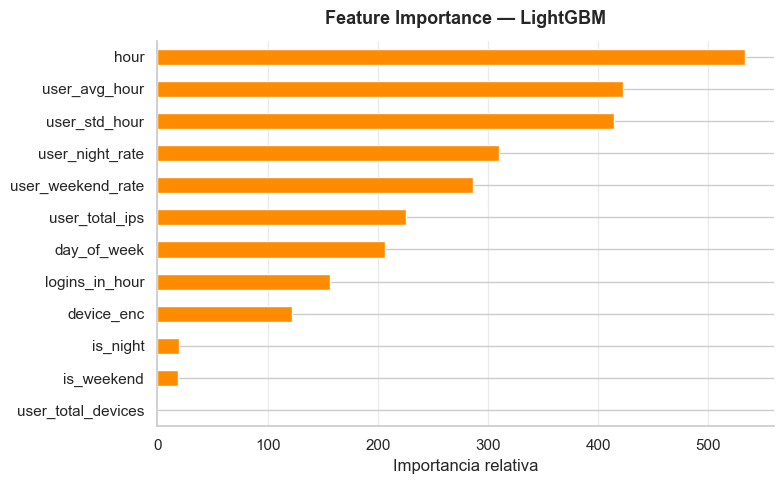

In [33]:
# LightGBM
feat_imp_lgbm = pd.Series(lgbm.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp_lgbm.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Feature Importance — LightGBM', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importancia relativa')
ax.grid(axis='x', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

In [34]:
# Comparar performance en train vs test para corroborar que no haya overfitting evidente (si el F1 en train es mucho mayor que en test, podría indicar overfitting)
for nombre, modelo in [('Random Forest', rf), ('LightGBM', lgbm)]:
    f1_train = f1_score(y_train, modelo.predict(X_train))
    f1_test  = f1_score(y_test,  modelo.predict(X_test))
    print(f'{nombre}:')
    print(f'  F1 train: {f1_train:.4f}')
    print(f'  F1 test:  {f1_test:.4f}')
    print(f'  Diferencia: {f1_train - f1_test:.4f}')

Random Forest:
  F1 train: 0.9451
  F1 test:  0.9208
  Diferencia: 0.0243
LightGBM:
  F1 train: 0.9395
  F1 test:  0.9254
  Diferencia: 0.0140


No se evidencia overfitting en los resultados.

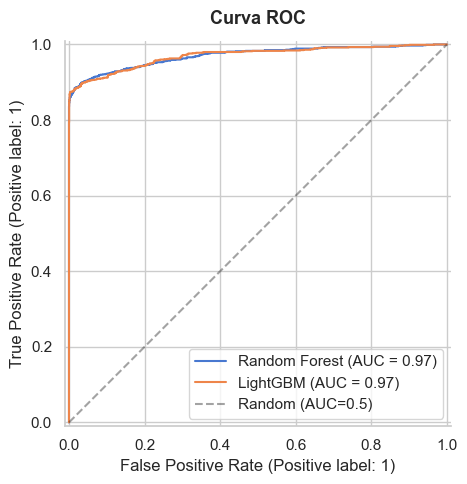

In [35]:
#Se grafica comparativamente la curva ROC de ambos modelos para evaluar su capacidad de discriminación entre clases.
y_prob_rf   = rf.predict_proba(X_test)[:, 1]
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

roc_rf   = roc_auc_score(y_test, y_prob_rf)
roc_lgbm = roc_auc_score(y_test, y_prob_lgbm)

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_rf,   ax=ax, name=f'Random Forest')
RocCurveDisplay.from_predictions(y_test, y_prob_lgbm, ax=ax, name=f'LightGBM')
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (AUC=0.5)')

ax.set_title('Curva ROC', fontsize=13, fontweight='bold', pad=12)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

#### SMOTE

Se volvera a entrenar el modelo de LightGBM esta vez usando SMOTE para el balanceo de las clases, para ver si hay una mejora de rendimiento.

In [36]:
def objective_lgbm_smote(trial):
    smote_params = {
        'k_neighbors': trial.suggest_int('k_neighbors', 3, 10), #Se buscara el mejor número de vecinos para SMOTE entre 3 y 10
    }
    
    model_params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1
    }
    
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42, **smote_params)),
        ('clf', LGBMClassifier(**model_params))
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()
    return score

lgbm_smote = optuna.create_study(direction='maximize')
lgbm_smote.optimize(objective_lgbm_smote, n_trials=30, show_progress_bar=True)

print(f'Mejores params: {lgbm_smote.best_params}')


  0%|          | 0/30 [00:00<?, ?it/s]

Mejores params: {'k_neighbors': 8, 'n_estimators': 500, 'max_depth': 12, 'learning_rate': 0.050774730942031554, 'num_leaves': 22, 'min_child_samples': 8, 'subsample': 0.7236397245787681, 'colsample_bytree': 0.9105640958261665}


In [37]:
# Modelo final con SMOTE
lgbm_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=8)),
    ('clf', LGBMClassifier(**lgbm_smote.best_params, random_state=42, verbose=-1))
])
lgbm_smote.fit(X_train, y_train)

# Comparación
for nombre, modelo in [('LGBM class_weight', lgbm), ('LGBM + SMOTE', lgbm_smote)]:
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    print(f'\n=== {nombre} ===')
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomalía']))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
    print(f'PR-AUC:  {average_precision_score(y_test, y_prob):.4f}')


=== LGBM class_weight ===
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98      2789
    Anomalía       0.98      0.88      0.93      1000

    accuracy                           0.96      3789
   macro avg       0.97      0.93      0.95      3789
weighted avg       0.96      0.96      0.96      3789

ROC-AUC: 0.9704
PR-AUC:  0.9579

=== LGBM + SMOTE ===
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98      2789
    Anomalía       0.98      0.88      0.93      1000

    accuracy                           0.96      3789
   macro avg       0.97      0.93      0.95      3789
weighted avg       0.96      0.96      0.96      3789

ROC-AUC: 0.9705
PR-AUC:  0.9582


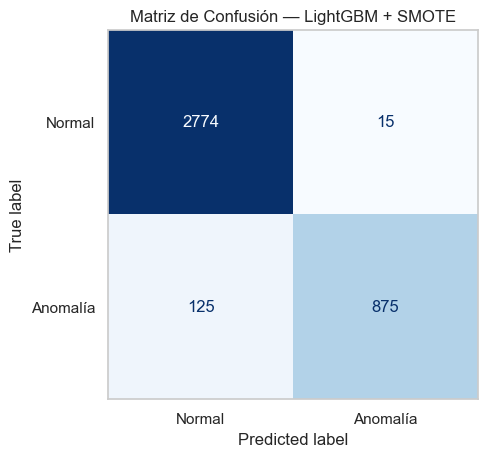

In [38]:
#Matriz de confusión para LightGBM + SMOTE
cm_smote = confusion_matrix(y_test, lgbm_smote.predict(X_test))
disp = ConfusionMatrixDisplay(cm_smote, display_labels=['Normal', 'Anomalía'])
disp.plot(cmap='Blues', colorbar=False)
disp.ax_.grid(False)
plt.title('Matriz de Confusión — LightGBM + SMOTE')
plt.show()

Podemos evidenciar que los resultados son prácticamente idénticos con y sin SMOTE, lo que confirma que para desbalances moderados class_weight='balanced' es suficiente y más eficiente. SMOTE agrega complejidad computacional sin beneficio real en este caso.